# Invoice Data Quality & Item Analysis


In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import mysql.connector

# Load credentials from .env - never hardcode these
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), '.env'))
load_dotenv()  # also try cwd in case notebook is run from project root

DB_HOST = os.environ['MYSQL_HOST']
DB_USER = os.environ['MYSQL_USER']
DB_PASS = os.environ['MYSQL_PASSWORD']
DB_NAME = os.environ['MYSQL_DB']

engine = create_engine(f'mysql+mysqlconnector://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}')
conn   = mysql.connector.connect(host=DB_HOST, user=DB_USER, password=DB_PASS, database=DB_NAME)

def q(sql):
    with engine.connect() as con:
        return pd.read_sql(text(sql), con)

print('Connected.')

Connected.


## 1. Row Counts

In [2]:
counts = q("""
    SELECT
        (SELECT COUNT(*) FROM invoices)        AS invoices,
        (SELECT COUNT(*) FROM line_items)      AS line_items,
        (SELECT COUNT(*) FROM suppliers)       AS suppliers,
        (SELECT COUNT(*) FROM clients)         AS clients,
        (SELECT COUNT(*) FROM invoice_images)  AS images,
        (SELECT COUNT(*) FROM suppliers WHERE email IS NOT NULL) AS supplier_emails,
        (SELECT COUNT(*) FROM clients   WHERE email IS NOT NULL) AS client_emails
""")
for col in counts.columns:
    print(f'  {col:<25} {int(counts[col].iloc[0])}')

  invoices                  3829
  line_items                14933
  suppliers                 3829
  clients                   3829
  images                    5189
  supplier_emails           313
  client_emails             164


## 2. Null Investigation & Backfill
Recover missing financial fields from raw_data where possible.
VAT can be derived: if net_worth and gross_worth are both present, vat_amount = gross_worth - net_worth.
date_of_issue and net_worth/gross_worth cannot be fabricated - genuinely missing = unprocessable.

In [3]:
from dateutil import parser as dateparser

cursor = conn.cursor()

cursor.execute("""
    SELECT id, net_worth, vat_percent, vat_amount, gross_worth, date_of_issue, raw_data
    FROM invoices
    WHERE net_worth IS NULL OR vat_amount IS NULL OR gross_worth IS NULL
      OR date_of_issue IS NULL OR vat_percent IS NULL
""")
null_rows = cursor.fetchall()
print(f'Invoices with at least one null field: {len(null_rows)}')

recovered = {'gross_worth': 0, 'net_worth': 0, 'vat_amount': 0,
             'vat_amount_derived': 0, 'vat_percent': 0, 'date_of_issue': 0}
not_recoverable = 0

def safe_dict(raw_data):
    if raw_data is None: return None
    if isinstance(raw_data, dict): return raw_data
    if isinstance(raw_data, (bytes, bytearray)):
        raw_data = raw_data.decode('utf-8', errors='replace')
    if isinstance(raw_data, str):
        try: return json.loads(raw_data)
        except Exception: return None
    return None

def get_val(data, *keys):
    if not isinstance(data, dict): return None
    for k in keys:
        v = data.get(k)
        if v is not None: return v
    return None

def parse_date(val):
    if not isinstance(val, str): return None
    try: return dateparser.parse(val, dayfirst=False).strftime('%Y-%m-%d')
    except Exception: return None

for row in null_rows:
    inv_id, net_worth, vat_pct, vat_amount, gross_worth, date_of_issue, raw_data = row
    data = safe_dict(raw_data)
    if not isinstance(data, dict):
        not_recoverable += 1
        continue

    summary = data.get('summary') if isinstance(data.get('summary'), dict) else {}
    updates = {}

    # gross_worth
    if gross_worth is None:
        v = get_val(data, 'total_due', 'total_gross_worth') or get_val(summary, 'gross_worth', 'total_gross_worth')
        if isinstance(v, (int, float)) and v > 0:
            updates['gross_worth'] = float(v); recovered['gross_worth'] += 1

    # net_worth
    if net_worth is None:
        v = get_val(data, 'subtotal', 'total_net_worth') or get_val(summary, 'net_worth', 'total_net_worth')
        if isinstance(v, (int, float)) and v > 0:
            updates['net_worth'] = float(v); recovered['net_worth'] += 1

    # vat_amount - try raw_data first, then derive from gross-net
    if vat_amount is None:
        v = get_val(data, 'sales_tax', 'tax_amount')
        if v is None:
            tax = data.get('tax')
            if isinstance(tax, dict): v = tax.get('amount')
        if v is None:
            v = get_val(summary, 'vat', 'total_vat')
        if isinstance(v, (int, float)) and v >= 0:
            updates['vat_amount'] = float(v); recovered['vat_amount'] += 1
        else:
            # Derive: gross_worth - net_worth (use already-updated values if available)
            gw = updates.get('gross_worth', gross_worth)
            nw = updates.get('net_worth', net_worth)
            if isinstance(gw, (int, float)) and isinstance(nw, (int, float)) and gw > nw:
                updates['vat_amount'] = round(float(gw) - float(nw), 2)
                recovered['vat_amount_derived'] += 1

    # vat_percent
    if vat_pct is None:
        v = get_val(data, 'sales_tax_percent') or get_val(summary, 'vat_percent')
        if isinstance(v, (int, float)) and v > 0:
            updates['vat_percent'] = float(v); recovered['vat_percent'] += 1
        else:
            # Derive from vat_amount / net_worth
            va = updates.get('vat_amount', vat_amount)
            nw = updates.get('net_worth', net_worth)
            if isinstance(va, (int, float)) and isinstance(nw, (int, float)) and nw > 0:
                updates['vat_percent'] = round(float(va) / float(nw) * 100, 1)
                recovered['vat_percent'] += 1

    # date_of_issue - parse to YYYY-MM-DD, cannot be fabricated
    if date_of_issue is None:
        raw_date = get_val(data, 'invoice_date', 'date_of_issue', 'date')
        parsed = parse_date(raw_date)
        if parsed:
            updates['date_of_issue'] = parsed; recovered['date_of_issue'] += 1

    if updates:
        set_clause = ', '.join([f'{k} = %s' for k in updates])
        cursor.execute(f'UPDATE invoices SET {set_clause} WHERE id = %s',
                       list(updates.values()) + [inv_id])

conn.commit()
print('\nRecovered from raw_data:')
for field, count in recovered.items():
    print(f'  {field:<25} {count}')
print(f'No raw_data (unrecoverable): {not_recoverable}')

Invoices with at least one null field: 704

Recovered from raw_data:
  gross_worth               0
  net_worth                 0
  vat_amount                0
  vat_amount_derived        0
  vat_percent               165
  date_of_issue             0
No raw_data (unrecoverable): 0


## 3. Null Analysis & Rejection Counts
Strict policy: ALL financial fields + date_of_issue must be present to be processable.
VAT can be derived if at least one of vat_percent/vat_amount is available.
net_worth, gross_worth, date_of_issue cannot be fabricated - genuinely missing = REJECT.

In [4]:
invoices = q('SELECT id, invoice_number, date_of_issue, net_worth, vat_percent, vat_amount, gross_worth FROM invoices')

print('=== NULL COUNTS - INVOICES (post backfill) ===')
for col in invoices.columns:
    n   = invoices[col].isna().sum()
    pct = n / len(invoices) * 100
    flag = '  HIGH' if pct > 30 else ('  WARNING' if pct > 5 else '  OK')
    print(f'  {col:<20} {n:>5} nulls  ({pct:.1f}%){flag}')

# Strict rejection logic
critical = ['date_of_issue', 'net_worth', 'gross_worth']
# VAT: must have at least one of vat_percent or vat_amount
missing_critical = invoices[critical].isna().any(axis=1)
missing_vat      = invoices['vat_percent'].isna() & invoices['vat_amount'].isna()
will_reject      = missing_critical | missing_vat

print(f'\n=== REJECTION ANALYSIS (strict) ===')
print(f'  Missing date_of_issue:           {invoices["date_of_issue"].isna().sum()} → REJECT')
print(f'  Missing net_worth:                {invoices["net_worth"].isna().sum()} → REJECT')
print(f'  Missing gross_worth:              {invoices["gross_worth"].isna().sum()} → REJECT')
print(f'  Missing both vat fields:          {missing_vat.sum()} → REJECT')
print(f'  Total will be REJECTED:           {will_reject.sum()} ({will_reject.mean()*100:.1f}%)')
print(f'  Total processable:                {(~will_reject).sum()} ({(~will_reject).mean()*100:.1f}%)')

=== NULL COUNTS - INVOICES (post backfill) ===
  id                       0 nulls  (0.0%)  OK
  invoice_number           0 nulls  (0.0%)  OK
  date_of_issue          111 nulls  (2.9%)  OK
  net_worth              164 nulls  (4.3%)  OK
  vat_percent            494 nulls  (12.9%)  WARNING
  vat_amount             587 nulls  (15.3%)  WARNING
  gross_worth            248 nulls  (6.5%)  WARNING

=== REJECTION ANALYSIS (strict) ===
  Missing date_of_issue:           111 → REJECT
  Missing net_worth:                164 → REJECT
  Missing gross_worth:              248 → REJECT
  Missing both vat fields:          393 → REJECT
  Total will be REJECTED:           463 (12.1%)
  Total processable:                3366 (87.9%)


## 4. Null Analysis - Line Items
Strict: missing net_price or quantity flags the line item as unvalidatable for price checks.

In [5]:
items_raw = q('SELECT * FROM line_items')

print('=== NULL COUNTS - LINE ITEMS ===')
for col in items_raw.columns:
    n   = items_raw[col].isna().sum()
    pct = n / len(items_raw) * 100
    flag = '  HIGH' if pct > 30 else ('  WARNING' if pct > 5 else '  OK')
    print(f'  {col:<20} {n:>6} nulls  ({pct:.1f}%){flag}')

missing_price = items_raw['net_price'].isna().sum()
missing_qty   = items_raw['quantity'].isna().sum()
missing_worth = items_raw['net_worth'].isna().sum()
unvalidatable = (items_raw['net_price'].isna() | items_raw['quantity'].isna() | items_raw['net_worth'].isna()).sum()

print(f'\n  Items unvalidatable for price check (missing price, qty, or net_worth): {unvalidatable}')
print(f'  Total: {len(items_raw)} | avg {len(items_raw)/len(invoices):.1f} per invoice')

=== NULL COUNTS - LINE ITEMS ===
  id                        0 nulls  (0.0%)  OK
  invoice_id                0 nulls  (0.0%)  OK
  item_number             520 nulls  (3.5%)  OK
  description               0 nulls  (0.0%)  OK
  quantity                228 nulls  (1.5%)  OK
  unit_of_measure        2411 nulls  (16.1%)  WARNING
  net_price               241 nulls  (1.6%)  OK
  net_worth                 1 nulls  (0.0%)  OK
  vat_percent            2403 nulls  (16.1%)  WARNING
  gross_worth            1868 nulls  (12.5%)  WARNING

  Items unvalidatable for price check (missing price, qty, or net_worth): 241
  Total: 14933 | avg 3.9 per invoice


## 5. Item Categorisation

In [6]:
items_full = q('SELECT id, description, net_price, net_worth, quantity FROM line_items WHERE description IS NOT NULL')

category_rules = {
    'Computers & Gaming': [
        'computer','desktop','gaming','pc','intel','amd','ryzen','nvidia','gtx','rtx',
        'playstation','xbox','nintendo','switch','console','controller','gpu','cpu',
        'laptop','monitor','keyboard','mouse','workstation','gameboy','sega','wii',
        'ps2','ps3','ps4','ps5','vtech','projector','iwatch','apple watch','ipad','tablet',
        'ccna','cisco','video/official','exam dumps'
    ],
    'Shoes & Apparel': [
        'shoe','boot','sneaker','dress','shirt','pant','jacket','coat','sock',
        'cleat','sandal','slipper','hoodie','shorts','jeans','legging','blouse',
        'nike','adidas','puma','skechers','timberland','costume','pajama','cosplay',
        'jordan','curry','lebron','kobe','yeezy','under armour','new balance',
        'reebok','vans','converse','ll bean','roper','joma','sperry','boden',
        'lularoe','lands end','sz ','size ','toddler','youth','kid shoe','retro','oxford',
        'sunglasses','shades','jams world','hawaiian dress'
    ],
    'Furniture & Home Decor': [
        'rug','carpet','table','chair','sofa','couch','shelf','cabinet','desk',
        'ottoman','bench','stool','wardrobe','dresser','kilim','mat','doormat',
        'marble','knotted','woven','afghan','moroccan','turkish','bohemian','jute',
        'area rug','bath mat','runner','slipcover','futon','bedroom','living room',
        'furniture tool','moving wheel','slider','roller',
        'slip resistance covering','velcro'
    ],
    'Glassware & Bar': [
        'wine glass','goblet','stemware','champagne glass','tumbler','carafe','decanter',
        'corkscrew','bottle opener','wine opener','wine tool','cork cage','wine caddy',
        'wine basket','wine bottle','wine holder','wine barrel','wine rack','wine flute',
        'whiskey glass','cylinder glass','wild west wine','unicorn wine','vintage wine',
        'wine cooling','wine spoon','wine corker','corkit','wine pourer',
        'bottle holder','bottle display','bottle caddy','bottle rack','bottle cover',
        'bottle storage','bottle holder rack','holdups wine',
        'moonshine still','distiller','brewing pump','fruit cider','apple crusher',
        'active dry yeast','wine yeast','wine brewing','alcoholmeter','alcohol meter',
        'leather wine carrier','galvanized metal wine','rabbit wine','fruit press',
        'oak barrel','wooden barrel','roemer wine','german wine','champagne wine',
        'iridescent rainbow glass','cellar basics'
    ],
    'Books & Media': [
        # Format keywords - broad catch
        'hardcover','paperback','softcover','hardback','sealed illustrated','leather bound',
        'new sealed','ebook','e-book','epub','pdf','plr articles','e-books',
        'novel','autobiography','biography','cookbook','visual guide','field guide',
        'study guide','idiots guide',"idiot's guide",'reference book','handbook',
        'time life','dvd','on dvd','books on dvd','rare books',
        # Volume/series markers
        ' vol.',' vol ',' #',' no. ',' book ',' books ','series collection',
        # Author attribution
        ' by ',
        # Specific titles/series still slipping through
        'gilgamesh','wim hof','roseveare','american girl','an hour with jesus',
        'ex-kop','home stretch','dead time hank','tumbling by','nightmares in the sky',
        'language and woman','blooding by joseph','poor charlie','java how to program',
        'repair home laundry','experience by martin','high-yield behavioral',
        'walleye wisdom','summer places','cosmobiology','painting from the source',
        'american zoos','lives of the artists','battle of the dum','perry chan',
        'against all odds','a new earth','furiously happy','the italians by',
        'endurance shackleton','fall of berlin','hot zone','selected poetry',
        'admission assessment','die with zero','breaking free from depression',
        'shedd aquarium','photosynthesis by','picture of dorian gray',
        'playing blackjack','last victim','real world of jane austen',
        'little drummer girl','key to rebecca','rising tide of color',
        'morpheus road','the black morpheus','sasinowski','legacy of ra','heir of ra',
        'family tree','invisible life of addie','addie larue',
        'astronomy','visual guide','pretty good joke','little dreamer',
        'million little bricks','heroes feast','dungeons','d&d','cookbook',
        'battlestations','star trek','waterfowl','master and god',
        'scottish folklore','rare books on dvd','hornblower',
        'puzzle palace','the messiah','philadelphia museum',
        'sing my way home','history of the indians','story of a soul',
        'wayne gretzky','tea with jane','genealogical record','lds mormon',
        'vietnam decisive','herbal tarot','graphic design reference',
        'goodnight from london','gourmet','old vienna cookbook',
        'executive style','entertaining','world of art','o-zone',
        'van gogh time life','complete everyday cookbook','picturebook',
        'b000bmwn4i'
    ],
    'Sports & Outdoor': [
        'soccer','football','basketball','baseball','tennis','golf','camping',
        'bicycle','bike','fitness','gym','yoga','outdoor','picnic',
        'canoe','kayak','paddle','motorcycle journey'
    ],
    'Adhesives & Industrial': [
        'tape','adhesive','epoxy','resin','filler','masking','primer',
        'hardener','cartridge','cyanoacrylate','permabond','loctite',
        '3m ','tesa','araldite','sealant','sealer','activator',
        'spray adh','acrylic adh','hot melt','vhb','stikit','disc','belt',
        'ptfe','polyimide','glass cloth','graphite canvas',
        'filmtp','film tp','prot.tp','plating tape','d/c tape','duopak',
        'instant adh','nozzle','mixer','helical','cellulose tape',
        'glue dots','supertack','dynabrade','dynafile','devcon','dc rtv',
        'dc 786','dc #55','dc sylgard','epocast','akzo',
        'scotch-weld','o-ring lubricant','silicone grey',
        'mildew resist','mark 5 gun','manual gun','wool bonnet','hook pad',
        'filter reg','conversion kit','foam sheet','foam 7/8',
        'epocast','ec-1300','brushable ceramic','aluminum putty',
        'prim tr','prim (tr','dyn ii','bearing','blade',
        'velcro hook','fr3 001','activatior','sj8641'
    ],
    'Face Masks & PPE': [
        'mask','face mask','ppe','nitrile','glove','latex','medical glove','powder free'
    ],
    'Toys & Collectibles': [
        'lego','star wars','minifigure','stormtrooper','darth vader','yoda',
        'mandalorian','action figure','collectible','figurine','toy','doll',
        'pinning block','insect pin','photocard','tarot deck','album'
    ],
    'Jewellery & Accessories': [
        'necklace','bracelet','choker','pendant','jewelry','jewellery',
        'crystal grape','embellishment','boho women','multi-layer chain'
    ],
    'Bedding & Bath': [
        'bed sheet','bedding','pillow','comforter','duvet','quilt','towel',
        'bath','egyptian comfort','deep pocket'
    ],
    'Freight & Services': [
        'freight','shipping','delivery','handling','service charge','labour',
        'installation','setup fee','to be determined','staff services',
        'lead-time','test purpose','analytical services','server maintenance',
        'data services','machineries maintenance','aerospace fee',
        '10% aerospace','per line item'
    ],
}

def assign_category(d):
    if not d: return 'Uncategorised'
    dl = d.lower()
    for cat, kws in category_rules.items():
        if any(kw in dl for kw in kws):
            return cat
    return 'Uncategorised'

items_full['category'] = items_full['description'].apply(assign_category)

summary_cat = items_full.groupby('category').agg(
    count=('id','count'),
    avg_unit_price=('net_price','mean'),
).round(2).sort_values('count', ascending=False)

print(summary_cat.to_string())
uncat_n = (items_full['category']=='Uncategorised').sum()
print(f'\nUncategorised: {uncat_n} / {len(items_full)} ({uncat_n/len(items_full)*100:.1f}%)')

                         count  avg_unit_price
category                                      
Computers & Gaming        3493          239.16
Furniture & Home Decor    3343         2001.19
Shoes & Apparel           3040          103.74
Adhesives & Industrial    2176          267.37
Glassware & Bar           1200           33.78
Books & Media             1029           15.18
Uncategorised              333           20.78
Toys & Collectibles        109           16.43
Face Masks & PPE            89          122.63
Freight & Services          70          315.11
Sports & Outdoor            20            5.83
Bedding & Bath              18           17.26
Jewellery & Accessories     13           17.08

Uncategorised: 333 / 14933 (2.2%)


## 6. Remaining Uncategorised

In [7]:
uncat = items_full[items_full['category'] == 'Uncategorised']
if len(uncat) == 0:
    print('All items categorised.')
else:
    print(f'{len(uncat)} still uncategorised:')
    print(uncat['description'].value_counts().to_string())

333 still uncategorised:
description
Day Trading Joe Ross New Hard cover English edition                                  18
The Art of Glen Loates                                                               17
Florida's List of Protected Plants in Words and Pictures                             14
Q&A a Day: 5-Year Journal                                                            12
Pictures From a Distant Country: Seeing America Through Old Paper Money              12
Hekate Soteira : A Study of Hekate's Role in the Chaldean Oracles and Related...     11
KING JAMES VERSION (KJV), RAINBOW STUDY BIBLE, BLACK LEATHER with INDEX              11
Tales from the Buffalo Bills                                                         11
Dont Sweat the Small Stuff . . . and Its All Small Stuff: Simple Ways to Keep        11
Seashells of North America: A Guide to Field Ident                                   10
Evolutionary Analysis                                                              

## 7. Price Deviation Analysis
Unit price = net_worth / quantity (line total ÷ units ordered).
This is always the correct unit price regardless of what field name the source invoice used.
We only build a reference for items where pricing is consistent (cv ≤ 1.0, 3+ observations).
High deviations on reliable items are genuine anomalies.

In [8]:
price_data = q("""
    SELECT
        li.description,
        li.net_price,
        li.quantity,
        li.net_worth,
        -- Unit price: always net_worth / quantity
        -- net_worth IS the line total; net_price may be unit price OR line total depending on invoice format
        -- Dividing by quantity is the only consistent derivation
        CASE
            WHEN li.quantity IS NOT NULL AND li.quantity > 0 AND li.net_worth IS NOT NULL
            THEN ROUND(li.net_worth / li.quantity, 4)
            ELSE li.net_price
        END AS unit_price,
        i.invoice_number
    FROM line_items li
    JOIN invoices i ON li.invoice_id = i.id
    WHERE li.quantity IS NOT NULL AND li.quantity > 0
      AND li.net_worth IS NOT NULL
      AND li.description IS NOT NULL
""")

# Sanity check: verify net_worth = net_price * quantity for a sample
check = price_data[(price_data['net_price'] > 0) & (price_data['quantity'] > 0)].copy()
check['expected_total'] = check['net_price'] * check['quantity']
check['ratio'] = check['net_worth'] / check['expected_total']
close = ((check['ratio'] > 0.99) & (check['ratio'] < 1.01)).mean()
print(f'Rows where net_worth ≈ net_price × quantity (±1%): {close*100:.1f}%')
print(f'This confirms net_worth is the line total and net_price is the unit price in most cases.')
print(f'Outlier rows (ratio outside 0.99-1.01): {((check["ratio"]<0.99)|(check["ratio"]>1.01)).sum()}')
print()

# Build reference stats
stats = price_data.groupby('description')['unit_price'].agg(
    median='median', count='count', std='std', mean='mean'
).reset_index()
stats['cv'] = (stats['std'] / stats['mean']).fillna(0)

reliable = stats[(stats['count'] >= 3) & (stats['cv'] <= 1.0)].copy()
noisy    = stats[(stats['count'] >= 3) & (stats['cv'] >  1.0)]

print(f'Items with 3+ observations:        {len(stats[stats["count"]>=3])}')
print(f'Reliable (cv ≤ 1.0):               {len(reliable)}  ← used for price checks')
print(f'Too noisy (cv > 1.0):              {len(noisy)}  ← flagged as unknown price')

flagged = price_data.merge(reliable[['description','median']], on='description')
flagged.rename(columns={'median':'median_unit_price'}, inplace=True)
flagged['pct_dev'] = ((flagged['unit_price'] - flagged['median_unit_price']) / flagged['median_unit_price'] * 100).round(1)
flagged['abs_dev'] = flagged['pct_dev'].abs()

print(f'\nDeviations on reliable items ({len(flagged)} observations):')
print(f'  >5%  : {(flagged["abs_dev"]>5).sum():>5} ({(flagged["abs_dev"]>5).mean()*100:.1f}%)')
print(f'  >10% : {(flagged["abs_dev"]>10).sum():>5} ({(flagged["abs_dev"]>10).mean()*100:.1f}%)')
print(f'  >25% : {(flagged["abs_dev"]>25).sum():>5} ({(flagged["abs_dev"]>25).mean()*100:.1f}%)')

Rows where net_worth ≈ net_price × quantity (±1%): 97.2%
This confirms net_worth is the line total and net_price is the unit price in most cases.
Outlier rows (ratio outside 0.99-1.01): 418

Items with 3+ observations:        1470
Reliable (cv ≤ 1.0):               1431  ← used for price checks
Too noisy (cv > 1.0):              39  ← flagged as unknown price

Deviations on reliable items (13045 observations):
  >5%  :   650 (5.0%)
  >10% :   605 (4.6%)
  >25% :   528 (4.0%)


## 8. Worst Deviations

In [9]:
worst = flagged.nlargest(20, 'abs_dev')[[
    'invoice_number','description','net_price','quantity','net_worth',
    'unit_price','median_unit_price','pct_dev'
]].round(2)
print('net_price   = as stored in DB (from invoice source field)')
print('unit_price  = net_worth / quantity (always correct per-unit cost)')
print('Both should agree when data is consistent.\n')
print(worst.to_string(index=False))

net_price   = as stored in DB (from invoice source field)
unit_price  = net_worth / quantity (always correct per-unit cost)
Both should agree when data is consistent.

invoice_number                                         description  net_price  quantity  net_worth  unit_price  median_unit_price  pct_dev
               20 101740 4179 Prot.Tp. 12"x1000' CLEAR MOQ 6 rolls      482.0       3.0     1422.0      474.00              51.00    829.4
         35896   3M 201+ Masking Tape TAN 48mm x 55m 24 rolls/case      500.0       2.0     1000.0      500.00              61.75    709.7
           134   3M 201+ Masking Tape TAN 48mm x 55m 24 rolls/case      494.0       3.0     1459.0      486.33              61.75    687.6
                 3M 201+ Masking Tape TAN 48mm x 55m 24 rolls/case      494.0       3.0     1459.0      486.33              61.75    687.6
                 3M 201+ Masking Tape TAN 48mm x 55m 24 rolls/case      403.0       4.0     1568.0      392.00              61.75    534.

## 9. Price Reference Table

In [10]:
ref = reliable[['description','median','count']].copy()
ref.columns = ['description','median_unit_price','occurrences']
ref['lower_bound'] = (ref['median_unit_price'] * 0.95).round(2)
ref['upper_bound'] = (ref['median_unit_price'] * 1.05).round(2)
ref = ref.sort_values('occurrences', ascending=False)

print(f'Price reference table: {len(ref)} reliable items')
print(ref.head(20)[['description','median_unit_price','lower_bound','upper_bound','occurrences']].to_string(index=False))

Price reference table: 1431 reliable items
                                                                    description  median_unit_price  lower_bound  upper_bound  occurrences
                               Permabond 106 Cyanoacrylate 1-oz 10 bottles/case             108.00       102.60       113.40           54
                               3M 665 D/C Tape 12mm x 33m 72 rolls/case - boxed             165.00       156.75       173.25           52
               3M 426U Stikit PA Disc 5"xNH 100A 125 discs/roll | 10 rolls/case             200.00       190.00       210.00           51
                                          Activator CREAM 5-gal 5 gallons/pailt             148.00       140.60       155.40           49
                             3M DP460 EG Epoxy Adhesive - 50ml 2:1 12 kits/case             200.00       190.00       210.00           49
             Araldite 2012 GP Epoxy 50ml 6 cartridges/box | 120 cartridges/case             135.50       128.72       142.28     

## 10. Final Data State Summary

In [11]:
inv = q('SELECT id, invoice_number, date_of_issue, net_worth, vat_percent, vat_amount, gross_worth FROM invoices')
total = len(inv)

critical     = ['date_of_issue', 'net_worth', 'gross_worth']
missing_crit = inv[critical].isna().any(axis=1)
missing_vat  = inv['vat_percent'].isna() & inv['vat_amount'].isna()
will_reject  = missing_crit | missing_vat
processable  = (~will_reject).sum()

imgs = q('SELECT COUNT(*) AS n FROM invoice_images')
categorised = (items_full['category'] != 'Uncategorised').sum()
uncat_final = (items_full['category'] == 'Uncategorised').sum()

print('=== FINAL DATA STATE ===')
print(f'  Total invoices:              {total}')
print(f'  Processable (all fields OK): {processable} ({processable/total*100:.1f}%)')
print(f'  Will REJECT (missing data):  {will_reject.sum()} ({will_reject.mean()*100:.1f}%)')
print(f'  Known items for price check: {len(ref)}')
print(f'  Line items categorised:      {categorised} / {len(items_full)} ({categorised/len(items_full)*100:.1f}%)')
print(f'  Still uncategorised:         {uncat_final}')
print(f'  Images registered:           {int(imgs["n"].iloc[0])}')

cursor.close()
print('\nData analysis complete.')

=== FINAL DATA STATE ===
  Total invoices:              3829
  Processable (all fields OK): 3366 (87.9%)
  Will REJECT (missing data):  463 (12.1%)
  Known items for price check: 1431
  Line items categorised:      14600 / 14933 (97.8%)
  Still uncategorised:         333
  Images registered:           5189

Data analysis complete.


## 11. Visualisations

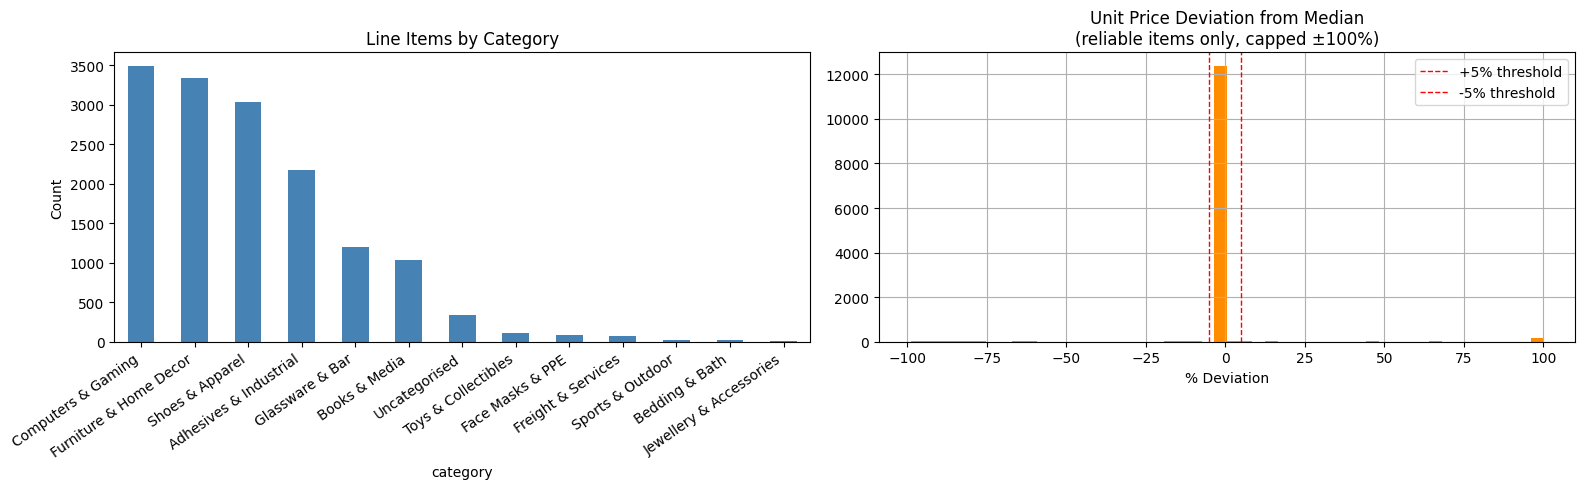

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

items_full['category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Line Items by Category')
axes[0].set_ylabel('Count')
plt.setp(axes[0].get_xticklabels(), rotation=35, ha='right')

flagged['pct_dev'].clip(-100, 100).hist(bins=50, ax=axes[1], color='darkorange', edgecolor='none')
axes[1].axvline(5,  color='red', linestyle='--', linewidth=1, label='+5% threshold')
axes[1].axvline(-5, color='red', linestyle='--', linewidth=1, label='-5% threshold')
axes[1].set_title('Unit Price Deviation from Median\n(reliable items only, capped ±100%)')
axes[1].set_xlabel('% Deviation')
axes[1].legend()

plt.tight_layout()
plt.show()